# 2025년 가을학기 중간고사 문제 - 비즈니스를 위한 데이터마이닝

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

from dmba import regressionSummary, exhaustive_search
from dmba import backward_elimination, forward_selection, stepwise_selection
from dmba import adjusted_r2_score, AIC_score, BIC_score

### dmba 라이브러리 설치할 것 
!pip install dmba

### 문제 1) 자동차 사고 (총 40점)

accidentsFull.csv 파일에는 세 단계 부상수준(NO INJURY, INJURY, FATALITY)으로 기록된 2001년 미국의 실제 자동차 사고 42,183건에 대한 정보가 담겨 있다. 각 사고에 대해 요일, 기상조건, 도로 종류와 같은 추가 정보도 기록되어 있다. 어떤 회사가 초기 보고서와 이 시스템의 연관된 데이터(그중 일부는 GPS-지원 보고에 의존함)에 근거하여 사고의 심각성을 신속하게 분류하는 시스템을 개발하고자 한다.
목적은 보고된 사고에 부상이 동반될지(MAX_SEV_IR = 1 또는 2), 부상이 없을지(MAX_SEV_IR = 0)를 예측하는 것이다. 

|컬럼	| 내용
|----|---------
| HOUR_I_R | 사고 발생 시간(주간, 야간)
| ALCHL_I | 음주 관련 사고 여부
| ALIGN_I | 도로의 정렬 상태(예: 직선, 곡선)를 나타냄
| STRATUM_R | 사고가 발생한 지역 또는 도로 유형을 나타내는 변수
| WRK_ZONE | 사고가 공사구역에서 발생했는지 여부
| WKDY_I_R | 사고가 발생한 요일
| INT_HWY | 사고가 주간 고속도로에서 발생했는지 여부
| LGTCON_I_R | 사고 당시 조명 상태(예: 주간, 야간, 가로등)를 나타내는 범주형 변수
| MANCOL_I_R | 충돌 유형
| PED_ACC_R | 보행자 사고 여부
| RELJCT_I_R | 사고가 교차로와 관련이 있는지 여부
| REL_RWY_R | 도로와 관련된 사고 유형
| PROFIL_I_R | 도로의 프로필(예: 평지, 경사)
| SPD_LIM | 사고가 발생한 도로의 제한 속도를 나타내는 수치형 변수
| SUR_COND | 도로 표면 상태(예: 건조, 젖음)를 나타내는 범주형 변수
| TRAF_CON_R | 사고 당시 교통 상황을 나타내는 범주형 변수
| TRAF_WAY | 교통량 또는 차선의 수
| VEH_INVL | 사고에 연루된 차량의 수
| WEATHER_R | 사고 당시 날씨 상태를 나타내는 범주형 변수
| INJURY_CRASH | 부상이 발생한 사고임을 나타내는 더미 변수
| NO_INJ_I | 부상자가 없었음을 나타내는 더미 변수
| PRPTYDMG_CRASH | 재산 피해가 발생한 사고임을 나타내는 더미 변수
| FATALITIES | 사망자 수
| MAX_SEV_IR | 부상 수준 (0, 1, 2)


- (1) 이를 위해 MAX_SEV_IR = 1 또는 2이면 값이 1이 되고 그렇지 않으면 0이 되는 INJURY라는 가변수를 생성하시오.(3점)

- (2) (1)에서 만든 INJURY가 목표변수이고, MAX_SEV_IR과 사고결과 관련 컬럼인 FATALITIES, PRPTYDMG_CRASH, NO_INJ_I, INJURY_CRASH를 제외한 나머지 변수들이 입력변수이다. 또, 입력변수 중 SPD_LIM, TRAF_WAY, VEH_INVL만 수치형 변수고 나머지 변수는 모두 범주형 변수이다. 이 범주형 변수들이 모두 int로 인식하고 있다. 범주형 유형으로 변경하라. (7점) 

- (3) 입력변수의 범주형 변수는 One Hot Encoding하라. (3점)

- (4) (3)까지 수행된 데이터를 가지고 의사결정나무 모형을 생성하기 위해 데이터를 학습집합과 테스트집합으로 나누어라. 무작위로 데이터를 나누며 테스트집합에는 전체집합의 30%가 포함되어야 한다.(5점)

- (5) (4)에서 만든 학습집합을 활용하여 최대 나무 의사결정나무 모형을 만들어라. 테스트집합을 대상으로 예측하여 성과를 roc_auc로 측정하라. 불순도지표는 default 값을 사용한다.(7점)

- (6) 의사결정나무 모형 학습 시 max_depth, min_samples_split, min_impurity_decrease 의 값을 변화시켜 가면서 성과가 가장 좋은 의사결정나무 모형을 찾고자 한다. max_depth의 값은 5, 10, 15, 20, min_samples_split은 20, 30, 40, 50, min_impurity_decrease는 0, 0.001, 0.002, 0.003을 사용하여 Grid Search를 수행하여라. 성과지표는 roc_auc를 사용하며 5겹 교차검증을 사용한다(GridSearchCV() 에서 scoring='roc_auc'로 지정). (4)에서 만든 학습집합을 활용하여 모형을 학습한다. 가장 좋은 모형의 성과를 보이고 이때의 max_depth, min_samples_split, min_impurity_decrease 값을 출력하라. (10점)

- (7) (6)에서 찾아진 가장 성과가 좋은 의사결정 나무 모형에서, 입력 변수 중요도를 파악하라.(5점)


### (1)

In [37]:
accidents = pd.read_csv('../data/accidentsFull.csv')
accidents.head()

,HOUR_I_R,ALCHL_I,ALIGN_I,STRATUM_R,WRK_ZONE,WKDY_I_R,INT_HWY,LGTCON_I_R,MANCOL_I_R,PED_ACC_R,...,SUR_COND,TRAF_CON_R,TRAF_WAY,VEH_INVL,WEATHER_R,INJURY_CRASH,NO_INJ_I,PRPTYDMG_CRASH,FATALITIES,MAX_SEV_IR
0,0,2,2,1,0,1,0,3,0,0,...,4,0,3,1,1,1,1,0,0,1
1,1,2,1,0,0,1,1,3,2,0,...,4,0,3,2,2,0,0,1,0,0
2,1,2,1,0,0,1,0,3,2,0,...,4,1,2,2,2,0,0,1,0,0
3,1,2,1,1,0,0,0,3,2,0,...,4,1,2,2,1,0,0,1,0,0
4,1,1,1,0,0,1,0,3,2,0,...,4,0,2,3,1,0,0,1,0,0


In [38]:
accidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42183 entries, 0 to 42182
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   HOUR_I_R        42183 non-null  int64
 1   ALCHL_I         42183 non-null  int64
 2   ALIGN_I         42183 non-null  int64
 3   STRATUM_R       42183 non-null  int64
 4   WRK_ZONE        42183 non-null  int64
 5   WKDY_I_R        42183 non-null  int64
 6   INT_HWY         42183 non-null  int64
 7   LGTCON_I_R      42183 non-null  int64
 8   MANCOL_I_R      42183 non-null  int64
 9   PED_ACC_R       42183 non-null  int64
 10  RELJCT_I_R      42183 non-null  int64
 11  REL_RWY_R       42183 non-null  int64
 12  PROFIL_I_R      42183 non-null  int64
 13  SPD_LIM         42183 non-null  int64
 14  SUR_COND        42183 non-null  int64
 15  TRAF_CON_R      42183 non-null  int64
 16  TRAF_WAY        42183 non-null  int64
 17  VEH_INVL        42183 non-null  int64
 18  WEATHER_R       42183 non-

In [39]:
accidents['INJURY'] = [ 0 if x == 0 else 1 for x in accidents.MAX_SEV_IR ]

In [40]:
accidents['INJURY'].value_counts()

1    21462
0    20721
Name: INJURY, dtype: int64

In [41]:
accidents.MAX_SEV_IR.value_counts()

1    20996
0    20721
2      466
Name: MAX_SEV_IR, dtype: int64

### (2)

In [42]:
y = accidents.INJURY
X = accidents.drop(['INJURY','FATALITIES', 'PRPTYDMG_CRASH', 'NO_INJ_I', 'INJURY_CRASH','MAX_SEV_IR'], axis=1)

In [46]:
# 제외할 컬럼 지정
exclude_cols = ['SPD_LIM', 'TRAF_WAY', 'VEH_INVL']

# 반복문을 통해 나머지 컬럼을 Categorical로 변환
for col in X.columns:
    if col not in exclude_cols:
        X[col] = pd.Categorical(X[col])

# 변환 결과 확인
print(X.dtypes)

HOUR_I_R      category
ALCHL_I       category
ALIGN_I       category
STRATUM_R     category
WRK_ZONE      category
WKDY_I_R      category
INT_HWY       category
LGTCON_I_R    category
MANCOL_I_R    category
PED_ACC_R     category
RELJCT_I_R    category
REL_RWY_R     category
PROFIL_I_R    category
SPD_LIM          int64
SUR_COND      category
TRAF_CON_R    category
TRAF_WAY         int64
VEH_INVL         int64
WEATHER_R     category
dtype: object


### (3)

In [47]:
X_one = pd.get_dummies(X)
X_one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42183 entries, 0 to 42182
Data columns (total 42 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SPD_LIM       42183 non-null  int64
 1   TRAF_WAY      42183 non-null  int64
 2   VEH_INVL      42183 non-null  int64
 3   HOUR_I_R_0    42183 non-null  uint8
 4   HOUR_I_R_1    42183 non-null  uint8
 5   ALCHL_I_1     42183 non-null  uint8
 6   ALCHL_I_2     42183 non-null  uint8
 7   ALIGN_I_1     42183 non-null  uint8
 8   ALIGN_I_2     42183 non-null  uint8
 9   STRATUM_R_0   42183 non-null  uint8
 10  STRATUM_R_1   42183 non-null  uint8
 11  WRK_ZONE_0    42183 non-null  uint8
 12  WRK_ZONE_1    42183 non-null  uint8
 13  WKDY_I_R_0    42183 non-null  uint8
 14  WKDY_I_R_1    42183 non-null  uint8
 15  INT_HWY_0     42183 non-null  uint8
 16  INT_HWY_1     42183 non-null  uint8
 17  INT_HWY_9     42183 non-null  uint8
 18  LGTCON_I_R_1  42183 non-null  uint8
 19  LGTCON_I_R_2  42183 non-n

### (4)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_one, y, test_size = 0.3)

### (5)

In [49]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [50]:
y_pred = dt.predict(X_test)
roc_auc_score(y_test, y_pred)

0.5673717240664992

### (6)

In [66]:
param_grid = {
    'max_depth': [5, 10, 15, 20], 
    'min_samples_split': [20, 30, 40, 50], 
    'min_impurity_decrease': [0, 0.001, 0.002, 0.003], 
}
gridSearch = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, n_jobs=-1, scoring='roc_auc')
gridSearch.fit(X_train, y_train)
print('Best score: ', gridSearch.best_score_)
print('Best parameters: ', gridSearch.best_params_)

Best score:  0.640316580713612
Best parameters:  {'max_depth': 10, 'min_impurity_decrease': 0, 'min_samples_split': 50}


### (7)

In [67]:
dt = DecisionTreeClassifier(max_depth=10, min_impurity_decrease=0, min_samples_split=50)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_impurity_decrease=0,
                       min_samples_split=50)

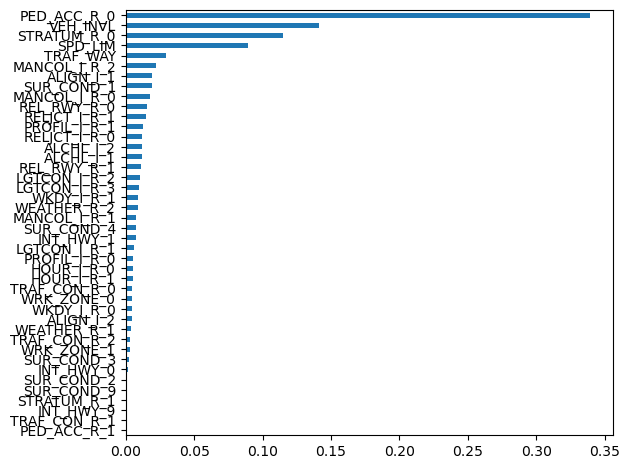

In [68]:
importances = dt.feature_importances_

df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
df = df.sort_values('importance')
#print(df)

ax = df.plot(kind='barh', x='feature', legend=False)
ax.set_ylabel('', fontsize = 7)
plt.tight_layout()
plt.show()

### 문제 2) 피싱 사이트 분류 (총 35점)

web-page-phishing.csv 데이터는 웹 페이지가 phishing 사이트인지 아닌지를 구분하는 데이터이며, 웹 페이지에 포함된 속성 정보를 포함하고 있다. 목표변수는 phishing이며 1이면 phishing 사이트이고, 0이면 phishing 사이트가 아니다. 각 속성은 다음과 같다.

|컬럼	| 내용
|----|---------
| url_length | The length of the URL
| n_dots | The count of ‘.’ characters in the URL
| n_hypens | The count of ‘-’ characters in the URL
| n_underline | The count of ‘_’ characters in the URL
| n_questionmark | The count of ‘?’ characters in the URL
| n_equal | The count of ‘=’ characters in the URL
| n_at | The count of ‘@’ characters in the URL
| n_and | The count of ‘&’ characters in the URL
| n_exclamation | The count of ‘!’ characters in the URL
| n_space | The count of ’ ’ characters in the URL
| n_tilde | The count of ‘~’ characters in the URL
| n_comma | The count of ‘,’ characters in the URL
| n_plus | The count of ‘+’ characters in the URL
| n_asterisk | The count of ‘*’ characters in the URL
| n_hastag | The count of ‘#’ characters in the URL
| n_dollar | The count of ‘$’ characters in the URL
| n_percent | The count of ‘%’ characters in the URL
| n_redirection | The count of redirections in the URL
| phishing | The Labels of the URL. 1 is phishing and 0 is legitimate

다음과 같은 과정을 거쳐 phishing 인지 아닌지를 분류하는 모형을 만들어보자.

나이브 베이즈를 사용해서 사이트가 phishing 인지 아닌지를 분류하는 모형을 만들고자한다. 

- (1) 입력변수로는 목표변수인 phishing과 url_length, n_redirection를 제외한 변수를 사용하며, 모형을 만들기 위해 필요한 데이터 전처리 과정을 수행하라. (5점)
- (2) phishing 컬럼에서 0인 사이트의 수와 1인 사이트의 수가 불균형하게 존재한다. 1인 사이트의 수를 over sampling하여 0인 사이트의 수와 동일하게 만들어라. over sampling 기법 중 어떠한 방법도 사용하여도 된다. (5점) 
- (3) (2)에서 만들어진 데이터를 활용하여 나이브 베이즈 모형을 생성하기 위해 전체 데이터를 학습집합과 테스트집합으로 나누어라. 무작위로 데이터를 나누며 테스트집합에는 전체집합의 20%가 포함되어야 한다. (5점)
- (4) (3)에서 만들어진 학습데이터로 나이브 베이즈 모형을 학습하여라. 생성한 나이브 베이즈 모형을 활용하여 테스트 데이터에 대해 분류하고, 정확도를 f1 score로 측정하여라. (5점)
- (5) 5겹 교차검증을 활용하여 나이브 베이즈 모형의 성과를 측정하고자 한다. 성과는 f1 score로 측정하며, 5겹 교차검증 성과의 평균치를 보여라. (5점)
- (6) (1)에서 만든 입력변수 집합을 표준정규분포로 표준화하고 PCA를 활용하여 2차원으로 축소하시오. 축소된 데이터를 이용하여 이를 시각화하고, 이때 Phishing 사이트와 No Phishing 사이트의 점 색을 다르게하여라. (10점)


### (1)

In [40]:
web = pd.read_csv('../data/web-page-phishing.csv')
web.head()

,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,37,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,126,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0,1,1
3,18,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,55,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [46]:
y = web.phishing
X = web.drop(['phishing','url_length', 'n_redirection'],axis=1)

### (2)

In [68]:
web.phishing.value_counts()

0    63715
1    36362
Name: phishing, dtype: int64

<Axes: title={'center': 'Count (target)'}>

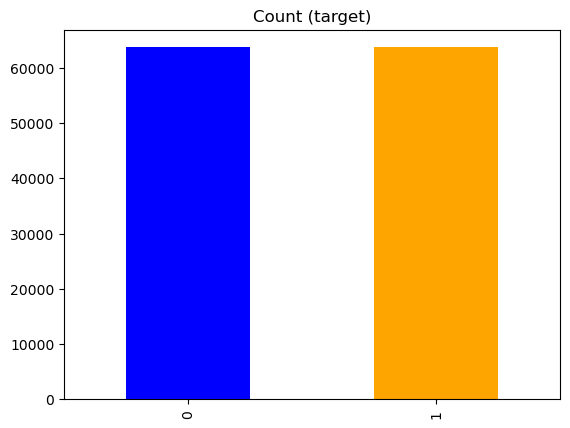

In [69]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler()
X_ros, y_ros = ros.fit_resample(X, y)

y_ros.value_counts().plot(kind='bar', title='Count (target)', color=['blue','orange'])

### (3)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X_ros, y_ros, test_size = 0.2)

### (4)

In [71]:
nb = MultinomialNB()
nb.fit(X_train,y_train)
y_pred = nb.predict(X_test)
f1_score(y_test, y_pred)

0.8133271320451567

### (5)

In [73]:
ave = cross_val_score(nb, X_ros, y_ros, scoring='f1', cv=5)
print(ave.mean())

0.8091469782399094


### (6)

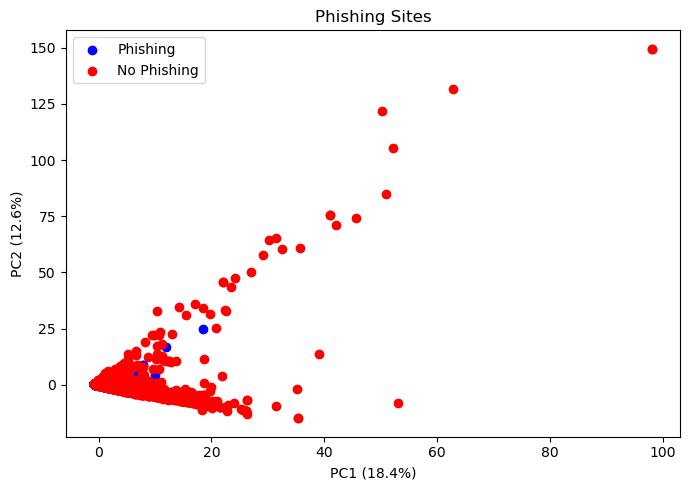

In [74]:
df = preprocessing.scale(X)

pcs = PCA(n_components=2)
df_pca = pcs.fit_transform(df)

plt.figure(figsize=(7, 5))

# y == 0인 점 (파란색)
plt.scatter(df_pca[y == 0, 0], df_pca[y == 0, 1], c='blue', label='Phishing')

# y == 1인 점 (빨간색)
plt.scatter(df_pca[y == 1, 0], df_pca[y == 1, 1], c='red', label='No Phishing')

plt.xlabel(f'PC1 ({pcs.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pcs.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Phishing Sites')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## 문제 3) 소프트웨어 재판매 이익 예측 (20점)

타이코 소프트웨어(Tayko Software)는 게임 및 교육용 소프트웨어를 판매하는 소프트웨어 카탈로그 회사다. 이 회사는 소프트웨어 제품 제조로 창업하였고 나중에 제품에 대한 제3의 소유권을 가지게 되었다. 최근 이 회사는 새로운 카탈로그에 들어갈 제품 목록을 수정해 이를 고객에게 우편 배송했다. 이 우편물 발송으로 2,000건의 구매 성과를 올렸다. 타이코 소프트웨어는 이 데이터를 기반으로 구매 고개의 소비 금액을 예측하는 모델을 고안하고자 한다. Tayko.csv 파일에는 2,000건의 구매 정보가 담겨 있다. 이 문제에서 사용된 변수는 대한 설명은 다음과 같다. (csv 파일에는 추가 변수들이 포함되어 있음.)

|컬럼	| 내용
|----|---------
| sequence_number | 행번호 
| source_a | 데이터 수집 원천 a 여부 (source_a,b,c,d,e,m,o,h,r,s,t,u,p,x,w 까지 있음)
| Freq | 전년도의 거래 건수
| last_update_days_ago | 고객 레코드 최종 갱신일로부터의 경과 일수
| 1st_update_days_ago | 고객 레코드 처음 갱신일로부터의 경과 일수
| Web order | 고객이 최소한 한 번 이상 인터넷 구매를 했는지 여부
| Gender=male | 남성 여부
| Address_is_res | 거주지 주소인지 여부
| US | 미국 주소지인지 여부
| Purchase | 테스트 우편물에 의한 구매 여부
| Spending | 테스트 우편물에 의한 구매액(단위: 달러)

- (1) 목표변수는 Spending이며, 입력변수는 Freq, last_update_days_ago, 1st_update_days_ago, Web order, Gender=male, Address_is_res, US 이다. 입력변수 중 범주형 변수에 해당하는 변수들은 범주형으로 변경하고, 가변수(dummy variable)로 만들어라. 학습집합과 테스트집합으로 무작위로 나누어라. 테스트집합에는 20%의 데이터가 속하게 분할하라. (5점)
- (2) 회귀 분석 모형을 만들려고 한다. 전역 탐색(exhaustive_search)을 통해서 입력변수를 결정하여라. 성과지표는 수정결정계수(adjusted R^2)를 활용하라. (5점)
- (3) (2)에서 찾아진 입력변수를 활용하여 회귀분석 모형을 만들고 5겹 교차 검증하고 성과의 평균을 보여라. 성과는 'neg_mean_squared_error'로 측정하라. (neg_mean_squared_error는 MSE 값에 음수를 취한 것이며, 오차지표이기에 적은 값이 좋은 모형임) (5점)
- (4) (2)에서 찾아진 입력변수를 활용하여 Lasso 회귀분석 모형을 만들고 5겹 교차 검증하고 성과의 평균을 보여라. alpha는 1.0으로 지정하자. 성과는 'neg_mean_squared_error'로 측정하라. (5점)

### (1)

In [77]:
tayko = pd.read_csv('../data/Tayko.csv')
tayko.head()

,sequence_number,US,source_a,source_c,source_b,source_d,source_e,source_m,source_o,source_h,...,source_x,source_w,Freq,last_update_days_ago,1st_update_days_ago,Web order,Gender=male,Address_is_res,Purchase,Spending
0,1,1,0,0,1,0,0,0,0,0,...,0,0,2,3662,3662,1,0,1,1,128
1,2,1,0,0,0,0,1,0,0,0,...,0,0,0,2900,2900,1,1,0,0,0
2,3,1,0,0,0,0,0,0,0,0,...,0,0,2,3883,3914,0,0,0,1,127
3,4,1,0,1,0,0,0,0,0,0,...,0,0,1,829,829,0,1,0,0,0
4,5,1,0,1,0,0,0,0,0,0,...,0,0,1,869,869,0,0,0,0,0


In [76]:
tayko.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   sequence_number       2000 non-null   int64
 1   US                    2000 non-null   int64
 2   source_a              2000 non-null   int64
 3   source_c              2000 non-null   int64
 4   source_b              2000 non-null   int64
 5   source_d              2000 non-null   int64
 6   source_e              2000 non-null   int64
 7   source_m              2000 non-null   int64
 8   source_o              2000 non-null   int64
 9   source_h              2000 non-null   int64
 10  source_r              2000 non-null   int64
 11  source_s              2000 non-null   int64
 12  source_t              2000 non-null   int64
 13  source_u              2000 non-null   int64
 14  source_p              2000 non-null   int64
 15  source_x              2000 non-null   int64
 16  source

In [78]:
y = tayko.Spending
X = tayko.drop(['Spending','Purchase','sequence_number','source_a','source_b','source_c','source_d','source_e','source_m','source_o','source_h','source_r','source_s','source_t','source_u','source_p','source_x','source_w'], axis=1)

In [85]:
# 제외할 컬럼 지정
exclude_cols = ['Freq', 'last_update_days_ago', '1st_update_days_ago']

# 반복문을 통해 나머지 컬럼을 Categorical로 변환
for col in X.columns:
    if col not in exclude_cols:
        X[col] = pd.Categorical(X[col])

# 변환 결과 확인
print(X.dtypes)

US                      category
Freq                       int64
last_update_days_ago       int64
1st_update_days_ago        int64
Web order               category
Gender=male             category
Address_is_res          category
dtype: object


In [86]:
X_ohe = pd.get_dummies(X)

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X_ohe, y, test_size=0.2)

### (2)

In [88]:
def train_model(variables):
    model = LinearRegression()
    model.fit(X_train[variables], y_train)
    return model

def score_model(model, variables):
    y_pred = model.predict(X_train[variables])
    # we negate as score is optimized to be as low as possible
    return -adjusted_r2_score(y_train, y_pred, model)

allVariables = X_train.columns
results = exhaustive_search(allVariables, train_model, score_model)

data = []
for result in results:
    model = result['model']
    variables = result['variables']
    AIC = AIC_score(y_train, model.predict(X_train[variables]), model)
    
    d = {'n': result['n'], 'r2adj': -result['score'], 'AIC': AIC}
    d.update({var: var in result['variables'] for var in allVariables})
    data.append(d)
pd.set_option('display.width', 100)
print(pd.DataFrame(data, columns=('n', 'r2adj', 'AIC') + tuple(sorted(allVariables))))
pd.reset_option('display.width')

     n     r2adj           AIC  1st_update_days_ago  Address_is_res_0  Address_is_res_1  Freq  \
0    1  0.475490  20131.685825                False             False             False  True   
1    2  0.504882  20040.417367                False              True             False  True   
2    3  0.507316  20033.529160                False              True             False  True   
3    4  0.509728  20026.672593                 True              True             False  True   
4    5  0.511437  20022.083274                 True              True             False  True   
5    6  0.511697  20022.228097                 True              True             False  True   
6    7  0.511696  20023.225251                 True              True             False  True   
7    8  0.511389  20025.225251                 True              True             False  True   
8    9  0.511082  20027.225251                 True              True             False  True   
9   10  0.510774  20029.225251

### (3)

In [90]:
reg = LinearRegression()
ave = cross_val_score(reg, X_ohe, y, scoring='neg_mean_squared_error', cv=5)
print(ave.mean())

-17239.59693826861


### (4)

In [91]:
las = Lasso(alpha=1.0)
ave = cross_val_score(las, X_ohe, y, scoring='neg_mean_squared_error', cv=5)
print(ave.mean())

-17246.036558595246


## 문제 4) 이 수업에서 개선해야 하는 점은 무엇인가? (작성 시 5점, 미작성 시 0점)